In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from hampel import hampel

In [4]:
import os

print(os.getcwd())
print(os.listdir("."))

C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026
['.ipynb_checkpoints', '.~BridgeLevellogger.6.23.26.csv', '.~P1_All_6.16.csv', '.~Well_Sampling_Data_P1.csv', 'AllPTemps.ipynb', 'bell2026.yml', 'BridgeLevellogger.6.23.26.csv', 'channel 1_UTC_20260410_155519.270.xml', 'CreeksBell2026.ipynb', 'filteredhobo1.xlsx', 'GenericBell2026-Copy1.ipynb', 'GenericTESTBell2026.ipynb', 'LeveloggerFiles.ipynb', 'Manual_Data_P1.csv', 'NOAAHastingsDam2.csv', 'NOAAHastingsDam2Since2024.csv', 'P1Bell2026.ipynb', 'P1ManualData.csv', 'P1SPCBell2026.ipynb', 'P1_All_6.16.csv', 'P1_creek_current.csv', 'P1_current.csv', 'P1_Day_June15Only.csv', 'P1_Month_MayOnly.csv', 'P1_SPC_Calibration.csv', 'P2Bell2026-Copy1.ipynb', 'P2ManualData.csv', 'P2SPCBell2026.ipynb', 'P2_creek_current.csv', 'P2_current.csv', 'P3Bell2026-Copy1.ipynb', 'P3ManualData.csv', 'P3_current.csv', 'P4Bell2026.ipynb', 'P4ManualData.csv', 'P4_creek_current.csv', 'P4_current.csv', 'P5Bell2026.ipynb', 'P5ManualData.csv', 'P5_creek_cur

In [5]:
hobodf = pd.read_csv("P4_current.csv")
mandf = pd.read_csv("P4ManualData.csv")
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"])
mandf["Date"] = pd.to_datetime(mandf["Date"])

In [6]:
hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
0,2026-01-27 15:34:38,-4.908627,0.000000,0.000000,-0.006693,0.000000
1,2026-01-27 15:49:38,8.031559,440.457458,684.298523,0.317648,286.297333
2,2026-01-27 16:04:38,8.234348,445.376068,687.392212,0.319535,289.494446
3,2026-01-27 16:19:38,8.318424,447.073822,688.137329,0.320057,290.597961
4,2026-01-27 16:34:38,8.346470,447.895142,688.777161,0.320420,291.131836
...,...,...,...,...,...,...
14108,2026-06-23 15:34:38,9.987675,477.324066,697.086853,0.327392,310.260620
14109,2026-06-23 15:49:38,9.987675,477.318451,697.078674,0.327388,310.256989
14110,2026-06-23 16:04:38,9.987675,477.299500,697.050964,0.327374,310.244659
14111,2026-06-23 16:19:38,9.987675,477.323120,697.085449,0.327391,310.260010


In [7]:
print(hobodf["Specific Conductivity"])

0          0.000000
1        684.298523
2        687.392212
3        688.137329
4        688.777161
            ...    
14108    697.086853
14109    697.078674
14110    697.050964
14111    697.085449
14112    697.045410
Name: Specific Conductivity, Length: 14113, dtype: float64


In [8]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
filteredhobo = hampel(hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(filteredhobo.filtered_data)

0          0.000000
1        684.298523
2        687.392212
3        688.137329
4        688.777161
            ...    
14108    697.086853
14109    697.078674
14110    697.050964
14111    697.085449
14112    697.045410
Length: 14113, dtype: float32


In [9]:
#type(filteredhobo)
#type(hobodate)

#filteredhobo = filteredhobo.reshape(hobodate.shape)
filteredhoboseries = pd.Series(filteredhobo.filtered_data, index = hobodf.index)
#type(filteredhoboseries)
filteredhobo = filteredhoboseries[1:]              #I used the google AI overview for this line of code :/

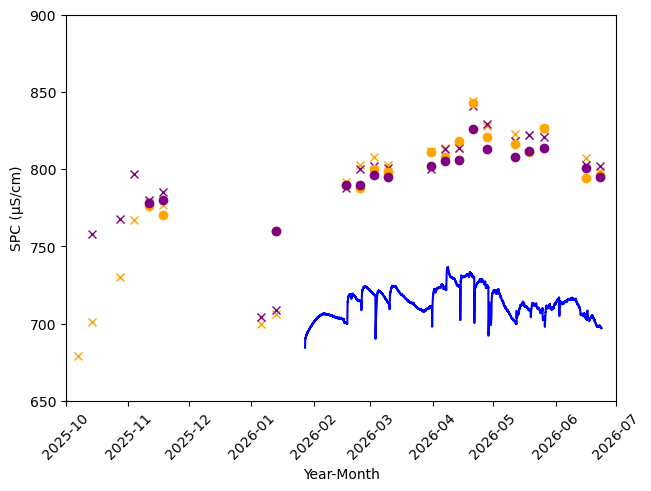

In [13]:
# hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  
# hobodf = pd.read_csv("P5_current.csv")
# mandf = pd.read_csv("P5ManualData.csv")
# mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time"]
slicedhobodate = hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(slicedhobodate, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.ylim((650, 900))
plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-07")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
slicedhobodate = hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(slicedhobodate, filteredhobo, s = 0.3, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
#finding the calibration factor
# hobodf = pd.read_csv("P1_All_6.16.csv")
# hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
# mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
# mandf["Date"] = pd.to_datetime(mandf["Date"])

fig, ax = plt.subplots(layout='constrained')
ax.scatter(filteredhobo, mandf.loc[:,"SPC bottom before"], s = 0.3, color="green", label = "manual (bb) versus continuous")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')